# Data Drift Analysis

The selected CatBoost model demonstrated stable performance on the
validation and calibration datasets, but its performance deteriorated
substantially on the external test dataset.

Calibration:
- ROC-AUC = 0.830
- PR-AUC = 0.488

External test:
- ROC-AUC = 0.630
- PR-AUC = 0.022

Additionally, the positive class rate changed from approximately 11%
in the development dataset to approximately 0.44% in the external test set.

The purpose of this notebook is to investigate whether the performance
degradation can be explained by data drift.

In [1]:
import pandas as pd
import numpy as pn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Constants
RANDOM_SEED = 42
PATH_TO_TRAIN_DATA = '../data/train-FIN_ANA_DATA.xls'
PATH_TO_TEST_DATA = '../data/test-FIN_ANA_DATA.xls'

In [3]:
df_train = pd.read_excel(PATH_TO_TRAIN_DATA)
df_test= pd.read_excel(PATH_TO_TEST_DATA)

## Target Distribution shift

In [4]:
# unique values in the target variable
df_test['QUALITY_OF_LOAN'].value_counts()

QUALITY_OF_LOAN
G     4286
B       19
DF       4
SS       1
Name: count, dtype: int64

In [7]:
mapping = {
    'G': 0,
    'B': 1
}

# ['G', 'B']
known_classes = df_train['QUALITY_OF_LOAN'].unique()

df_test = df_test[
    df_test['QUALITY_OF_LOAN'].isin(known_classes)
].copy()

df_train['QUALITY_OF_LOAN'] = (
    df_train['QUALITY_OF_LOAN']
    .map(mapping)
)

df_test['QUALITY_OF_LOAN'] = (
    df_test['QUALITY_OF_LOAN']
    .map(mapping)
)

5 objects with "strange" target variables (DF and SS) were removed

In [13]:
def target_stats(name, y):
    return {
        'dataset': name,
        'n': len(y),
        'positive': y.sum(),
        'positive_rate': y.mean()
    }

target_distribution = pd.DataFrame([
    target_stats(
        'train',
        df_train['QUALITY_OF_LOAN']
    ),
    target_stats(
        'test',
        df_test['QUALITY_OF_LOAN']
    )
])

target_distribution

,dataset,n,positive,positive_rate
0,train,37408,4154,0.111046
1,test,4305,19,0.004413


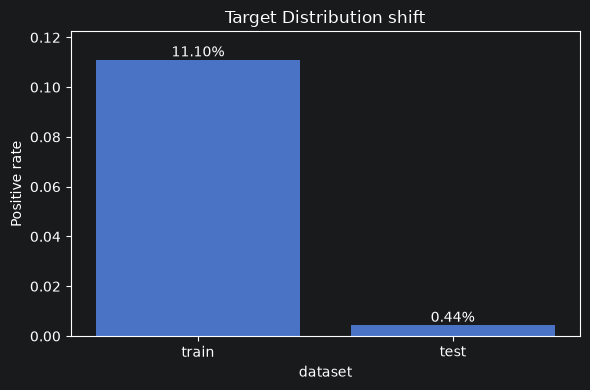

In [35]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=target_distribution, x='dataset', y='positive_rate')
ax.set_title('Target Distribution shift')
ax.bar_label(ax.containers[0],
             labels=[f'{val * 100:.2f}%' for val in target_distribution['positive_rate']])
ax.set_ylim(top=ax.get_ylim()[1] * 1.05)
ax.set_ylabel('Positive rate')
plt.tight_layout()
plt.show()

The positive class rate decreases from 11.1% in the train dataset
to 0.44% in the test dataset

This indicates a substantial target shift

## Missing-value drift

In [53]:
categorial_features = ['INF_MARITAL_STATUS', 'INF_GENDER',
                       'COMPENSATION_CHARGED', 'CLIENT_TYPE',
                       'REPAY_MODE']
numeric_features = ['INVESTMENT_TOTAL', 'ACCCURRENTBALANCE',
                    'INSTALL_SIZE', 'DUE_PAYMENT']

feature_columns = numeric_features + categorial_features

missing_train = df_train[feature_columns].isna().mean()
missing_test = df_test[feature_columns].isna().mean()

missing_df = pd.DataFrame({
    'train_missing_rate': missing_train,
    'test_missing_rate': missing_test
})

missing_df['diff'] = missing_df['test_missing_rate'] - missing_df['train_missing_rate']
missing_df.sort_values(by='diff', ascending=False)

,train_missing_rate,test_missing_rate,diff
CLIENT_TYPE,0.002753,0.018351,0.015597
INVESTMENT_TOTAL,0.000000,0.000000,0.000000
ACCCURRENTBALANCE,0.000000,0.000000,0.000000
DUE_PAYMENT,0.000000,0.000000,0.000000
REPAY_MODE,0.000000,0.000000,0.000000
INF_MARITAL_STATUS,0.000053,0.000000,-0.000053
INF_GENDER,0.000053,0.000000,-0.000053
COMPENSATION_CHARGED,0.000053,0.000000,-0.000053
INSTALL_SIZE,0.022402,0.000232,-0.022169


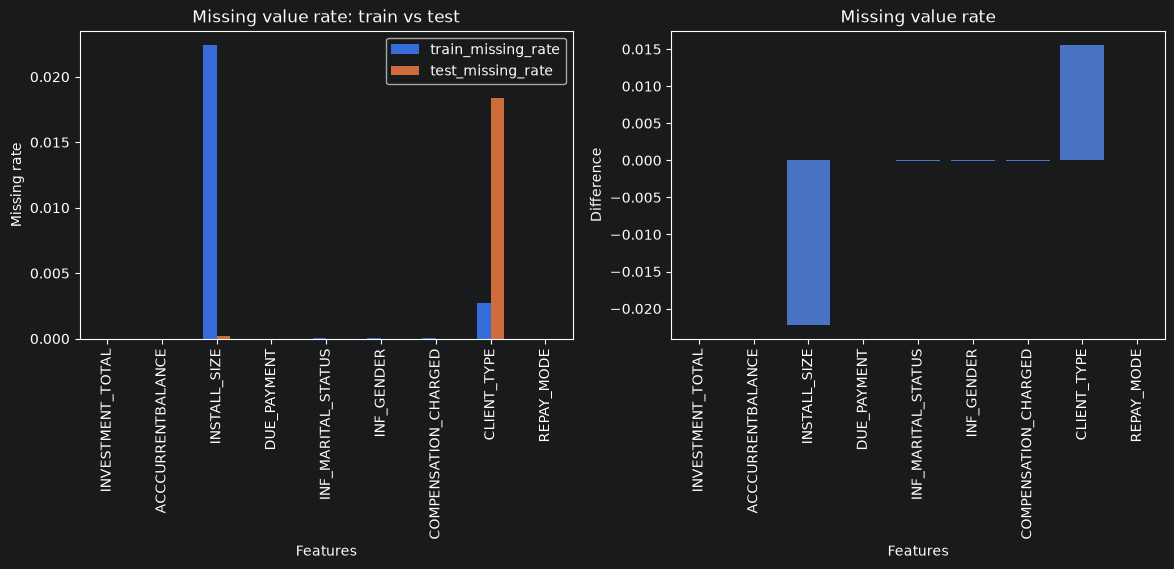

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
(ax1, ax2) = axes.flatten()

missing_df[
    ['train_missing_rate', 'test_missing_rate']
].plot(
    kind='bar',
    ax=ax1
)

ax1.set_title('Missing value rate: train vs test')
ax1.set_xlabel('Features')
ax1.set_ylabel('Missing rate')


sns.barplot(data=missing_df, x=missing_df.index, y='diff', ax=ax2)
ax2.set_title('Missing value rate')
ax2.set_xlabel('Features')
ax2.set_ylabel('Difference')
ax2.tick_params(axis='x', rotation=90)
plt.show()